# Notebook 01 — Direct Georectification

Projects every pixel in a nadir drone image onto the ground/water surface using:

1. **GPS position** — from EXIF (lat, lon, altitude)
2. **Camera orientation** — from DJI XMP gimbal angles (yaw, pitch, roll)
3. **Camera intrinsics** — focal length + sensor size from EXIF and camera database
4. **Direct georectification** — Beer-Lambert flat-surface projection (no GCPs required)

Outputs:
- `output/DJI_0061_georef.tif` — GeoTIFF (WGS-84)
- `output/DJI_0061_map.html` — Folium interactive map

**Drone**: DJI Phantom 3 | **Camera**: FC300C (1/2.3" sensor, f=3.61mm)

In [1]:
import sys
sys.path.insert(0, '../src')

import logging
logging.basicConfig(level=logging.INFO, format='%(levelname)s %(name)s: %(message)s')

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from pathlib import Path
from PIL import Image

%matplotlib inline
plt.rcParams['figure.figsize'] = (14, 6)

## 1. Configuration

In [2]:
DATA_DIR   = Path('../data')
OUTPUT_DIR = Path('../output')
OUTPUT_DIR.mkdir(exist_ok=True)

#IMAGE_PATH = DATA_DIR / 'DJI_0061.JPG'
IMAGE_PATH = DATA_DIR / 'DJI_0179.JPG'

# Camera calibration source: 'exif' | path to OpenCV YAML | Agisoft XML | Pix4D CSV
CAL_SOURCE = 'exif'

print(f'Image : {IMAGE_PATH}')
print(f'Exists: {IMAGE_PATH.exists()}')

Image : ../data/DJI_0179.JPG
Exists: True


## 2. Extract image metadata (GPS + orientation)

In [3]:
from direct_georef.metadata import read_metadata

meta = read_metadata(IMAGE_PATH)

print('=== Image Metadata ===')
print(f'Camera          : {meta.make} {meta.model}')
print(f'Image size      : {meta.image_width} × {meta.image_height} px')
print(f'Focal length    : {meta.focal_length_mm} mm  ({meta.focal_length_35mm} mm equiv)')
print()
print(f'GPS position    : {meta.latitude:.6f}°N,  {meta.longitude:.6f}°')
print(f'Altitude (abs)  : {meta.altitude_abs_m:.1f} m AMSL')
print(f'Altitude (rel)  : {meta.altitude_rel_m:.1f} m AGL  ← used for georectification')
print()
if meta.has_orientation:
    print('Gimbal (camera) :')
    print(f'  Yaw   = {meta.gimbal_yaw:+.2f}°  (heading from North, CW)')
    print(f'  Pitch = {meta.gimbal_pitch:+.2f}°  (-90 = straight down/nadir)')
    print(f'  Roll  = {meta.gimbal_roll:+.2f}°')
    print('Drone body      :')
    print(f'  Yaw   = {meta.flight_yaw:+.2f}°')
    print(f'  Pitch = {meta.flight_pitch:+.2f}°')
    print(f'  Roll  = {meta.flight_roll:+.2f}°')
else:
    print('WARNING: No gimbal orientation found — assuming nadir')

# DJI Mini 3


=== Image Metadata ===
Camera          : DJI FC3582
Image size      : 4032 × 3024 px
Focal length    : 6.72 mm  (24.0 mm equiv)

GPS position    : 58.473471°N,  9.240783°
Altitude (abs)  : 52.1 m AMSL
Altitude (rel)  : 91.6 m AGL  ← used for georectification

Gimbal (camera) :
  Yaw   = -114.20°  (heading from North, CW)
  Pitch = -89.90°  (-90 = straight down/nadir)
  Roll  = +0.00°
Drone body      :
  Yaw   = -147.30°
  Pitch = +2.60°
  Roll  = +3.70°


## 3. Load camera intrinsics

In [4]:
from direct_georef.camera import from_exif, from_opencv, from_agisoft_xml, from_pix4d_csv

if CAL_SOURCE == 'exif':
    camera = from_exif(
        focal_length_mm=meta.focal_length_mm,
        image_width=meta.image_width,
        image_height=meta.image_height,
        model=meta.model,
    )
elif CAL_SOURCE.endswith(('.yml', '.yaml', '.json')):
    camera = from_opencv(CAL_SOURCE)
elif CAL_SOURCE.endswith('.xml'):
    camera = from_agisoft_xml(CAL_SOURCE)
elif CAL_SOURCE.endswith('.csv'):
    camera = from_pix4d_csv(CAL_SOURCE)
else:
    raise ValueError(f'Unknown CAL_SOURCE: {CAL_SOURCE}')

print('=== Camera Model ===')
print(camera)
print()
print('Intrinsic matrix K:')
print(np.array2string(camera.K, precision=2, suppress_small=True))

=== Camera Model ===
CameraModel(fx=2807.78, fy=2806.81, cx=2016.00, cy=1512.00, distortion=no, label='EXIF+sensor (FC3582)')

Intrinsic matrix K:
[[2807.78    0.   2016.  ]
 [   0.   2806.81 1512.  ]
 [   0.      0.      1.  ]]


## 4. Run direct georectification

In [5]:
from direct_georef.georectify import georectify

result = georectify(meta, camera, full_grid=True)

print('=== Georectification Result ===')
print(f'Flying height   : {result.flying_height_m:.1f} m AGL')
print(f'GSD             : {result.gsd_m:.4f} m/px  ({result.gsd_m*100:.2f} cm/px)')
print(f'Pixel grid      : {result.lat_grid.shape}')
print()
print('Corner coordinates (lat, lon):')
for name, (lat, lon) in result.corners_latlon.items():
    print(f'  {name}: {lat:.6f}°N,  {lon:.6f}°')

# Compute actual footprint edge lengths
R_EARTH = 6_371_000.0
def dist_m(p1, p2):
    lat1, lon1 = np.radians(p1[0]), np.radians(p1[1])
    lat2, lon2 = np.radians(p2[0]), np.radians(p2[1])
    dlat = (lat2 - lat1) * R_EARTH
    dlon = (lon2 - lon1) * R_EARTH * np.cos((lat1 + lat2) / 2)
    return np.sqrt(dlat**2 + dlon**2)

c = result.corners_latlon
width_m  = dist_m(c['TL'], c['TR'])
height_m = dist_m(c['TL'], c['BL'])
print(f'Footprint       : {width_m:.1f} m × {height_m:.1f} m')
print(f'Expected        : {camera.width * result.gsd_m:.1f} m × {camera.height * result.gsd_m:.1f} m')

=== Georectification Result ===
Flying height   : 91.6 m AGL
GSD             : 0.0326 m/px  (3.26 cm/px)
Pixel grid      : (3024, 4032)

Corner coordinates (lat, lon):
  TL: 58.472748°N,  9.240470°
  TR: 58.473828°N,  9.239542°
  BR: 58.474191°N,  9.241090°
  BL: 58.473113°N,  9.242016°
Footprint       : 131.6 m × 98.7 m
Expected        : 131.4 m × 98.6 m


## 5. Visualise: original image + pixel coordinate grids

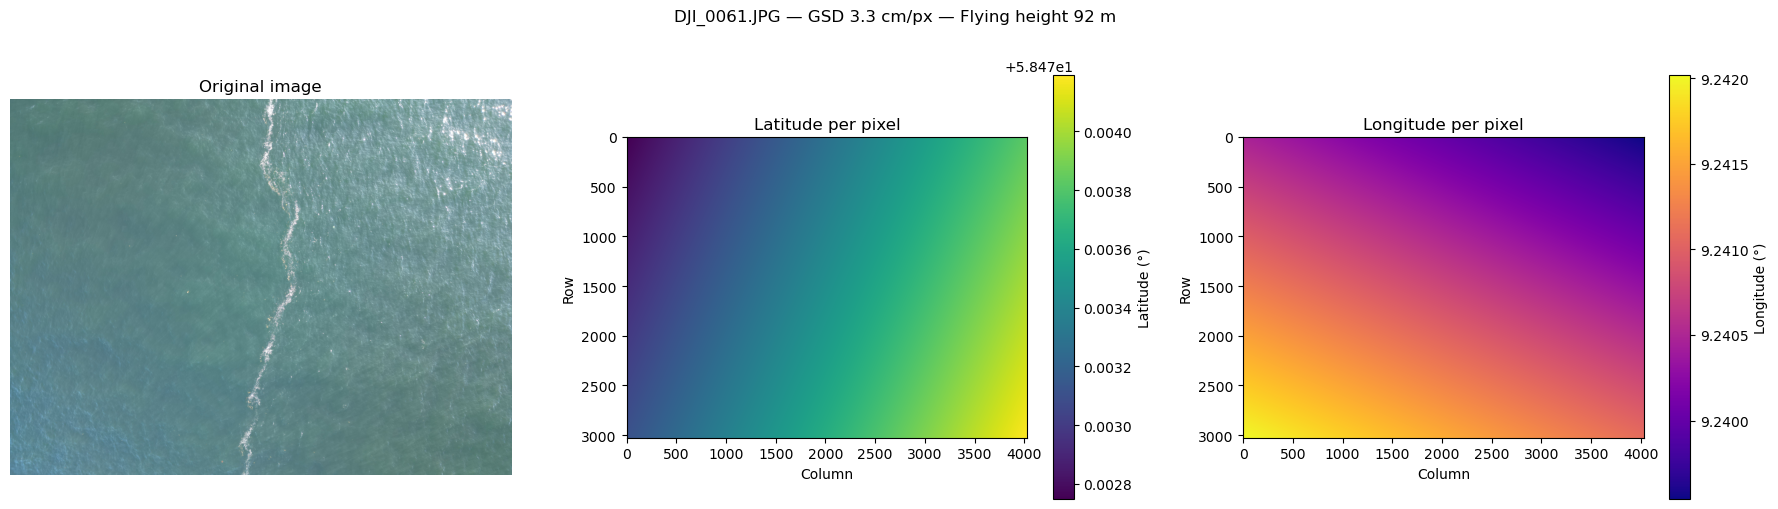

In [6]:
img = np.array(Image.open(IMAGE_PATH).convert('RGB'))
H, W = img.shape[:2]

# Sample every Nth pixel for quiver plot (avoid overplotting)
N = 80
rows = np.arange(0, H, N)
cols = np.arange(0, W, N)
rr, cc = np.meshgrid(rows, cols, indexing='ij')
sample_lat = result.lat_grid[rr, cc]
sample_lon = result.lon_grid[rr, cc]

fig, axes = plt.subplots(1, 3, figsize=(18, 5), tight_layout=True)

# Original image
axes[0].imshow(img)
axes[0].set_title('Original image')
axes[0].axis('off')

# Latitude grid
im1 = axes[1].imshow(result.lat_grid, cmap='viridis', origin='upper')
plt.colorbar(im1, ax=axes[1], label='Latitude (°)')
axes[1].set_title('Latitude per pixel')
axes[1].set_xlabel('Column'); axes[1].set_ylabel('Row')

# Longitude grid
im2 = axes[2].imshow(result.lon_grid, cmap='plasma', origin='upper')
plt.colorbar(im2, ax=axes[2], label='Longitude (°)')
axes[2].set_title('Longitude per pixel')
axes[2].set_xlabel('Column'); axes[2].set_ylabel('Row')

plt.suptitle(f'DJI_0061.JPG — GSD {result.gsd_m*100:.1f} cm/px — Flying height {result.flying_height_m:.0f} m', y=1.01)
plt.show()

## 6. Interactive Folium map

Map saved to: ../output/DJI_0061_map.html



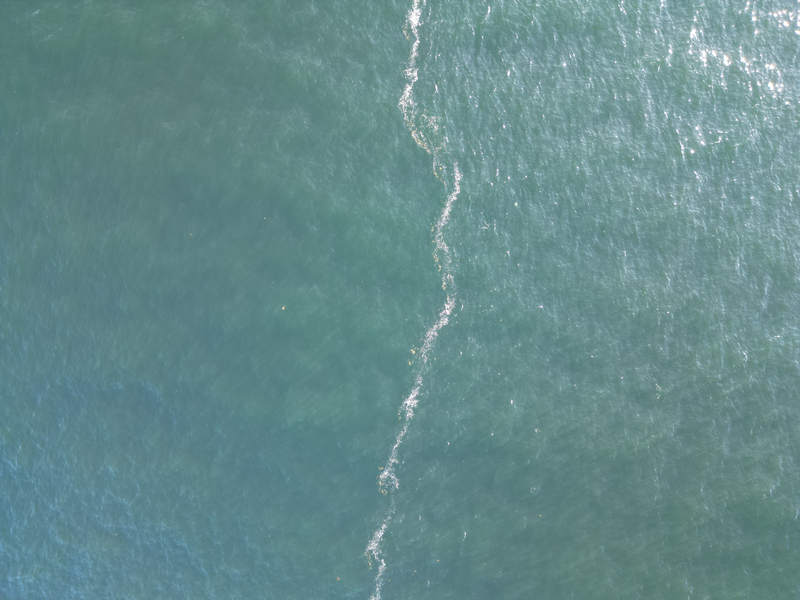

In [7]:
from direct_georef.export import to_folium_map

map_path = OUTPUT_DIR / 'DJI_0061_map.html'
m = to_folium_map(result, IMAGE_PATH, output_path=map_path, image_opacity=0.75)
print(f'Map saved to: {map_path}')
m  # display inline in Jupyter

## 7. Export GeoTIFF

In [8]:
from direct_georef.export import to_geotiff

# WGS-84 (EPSG:4326)
tif_path = OUTPUT_DIR / 'DJI_0061_georef.tif'
out = to_geotiff(result, IMAGE_PATH, tif_path, epsg=4326)
print(f'GeoTIFF saved : {out}')

import rasterio
with rasterio.open(out) as ds:
    print(f'CRS           : {ds.crs}')
    print(f'Transform     : {ds.transform}')
    print(f'Shape         : {ds.height} × {ds.width} px')
    b = ds.bounds
    print(f'Bounds (lon)  : {b.left:.6f} → {b.right:.6f}')
    print(f'Bounds (lat)  : {b.bottom:.6f} → {b.top:.6f}')

GeoTIFF saved : ../output/DJI_0061_georef.tif
CRS           : EPSG:4326
Transform     : |-0.00, 0.00, 9.24|
| 0.00, 0.00, 58.47|
| 0.00, 0.00, 1.00|
Shape         : 3024 × 4032 px
Bounds (lon)  : 9.239542 → 9.242017
Bounds (lat)  : 58.472749 → 58.474191


## 8. Footprint overview (matplotlib)

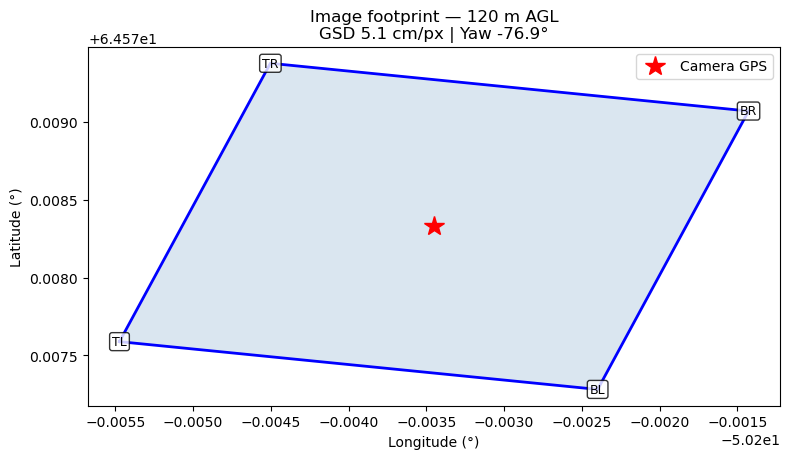

In [9]:
from matplotlib.patches import Polygon as MplPolygon
from matplotlib.collections import PatchCollection

fig, ax = plt.subplots(figsize=(8, 8))

# Plot footprint quadrilateral
corner_order = ['TL', 'TR', 'BR', 'BL']
xs = [result.corners_latlon[k][1] for k in corner_order]
ys = [result.corners_latlon[k][0] for k in corner_order]
xs.append(xs[0]); ys.append(ys[0])  # close

ax.fill(xs, ys, alpha=0.2, color='steelblue')
ax.plot(xs, ys, 'b-', linewidth=2)

# Label corners
for name in corner_order:
    lat, lon = result.corners_latlon[name]
    ax.annotate(name, xy=(lon, lat), fontsize=9, ha='center', va='center',
                bbox=dict(boxstyle='round,pad=0.2', facecolor='white', alpha=0.8))

# Camera position
ax.plot(meta.longitude, meta.latitude, 'r*', markersize=15, label='Camera GPS')

# Axes
ax.set_xlabel('Longitude (°)')
ax.set_ylabel('Latitude (°)')
ax.set_title(
    f'Image footprint — {result.flying_height_m:.0f} m AGL\n'
    f'GSD {result.gsd_m*100:.1f} cm/px | Yaw {meta.gimbal_yaw:+.1f}°'
)
ax.legend()
ax.set_aspect('equal')
plt.tight_layout()
plt.show()